# Análisis Exploratorio — Detección de Ideación Suicida

**Objetivo:** entender la forma del corpus de entrenamiento antes de tomar decisiones de preprocesamiento, vectorización y modelado. Todo el análisis se hace **únicamente sobre `data/data_train.csv`** — el fold de test (`data_test_fold1.csv`) permanece intocado para no contaminar la evaluación final.

Las decisiones que aparecen al final del notebook (qué se filtra, qué no, y por qué) se derivan directamente de los hallazgos numéricos de cada sección. No se toman a ciegas.

## 1. Setup y carga

In [1]:
import re
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolver el repo root desde el notebook (notebooks/ está un nivel debajo de la raíz)
REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.data_ingestion import data_loader, data_mapping, concatenate_df

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 100

In [2]:
DATA_PATH = REPO_ROOT / 'data' / 'data_train.csv'
EXPECTED_COLS = ['user_id', 'text_id', 'title', 'text', 'is_suicide']

df = data_loader(str(DATA_PATH), EXPECTED_COLS)
df = data_mapping(df, 'is_suicide', 'yes', 'no')
print(f'Forma: {df.shape}')
df.head(3)

Data Loaded, schema valid
Forma: (1516, 5)


,user_id,text_id,title,text,is_suicide
0,user0001,752d198d88af,Need help,"Hi I don't really know how to phrase this situation but I'll try. My life is at a really good point right now, I'm n...",0
1,user0002,e1ef76811148,feeling so overwhelmed and hopeless,i have been so depressed these past couple weeks ever since i got back from vacation normal life and reality has hit...,1
2,user0003,110179c6a4b8,"Nothing matters anymore, getting worse","Hi..I don't know where else to go. I am devastated right now, feeling like I'm spiraling out of control, I feel so f...",0


## 2. Schema y valores faltantes

Antes de cualquier análisis, verificar que el esquema es el esperado y que no haya valores nulos que vayan a romper el flujo.

In [3]:
print('Dtypes:')
print(df.dtypes)
print()
print('Valores nulos por columna:')
print(df.isna().sum())

Dtypes:
user_id         str
text_id         str
title           str
text            str
is_suicide    int64
dtype: object

Valores nulos por columna:
user_id       0
text_id       0
title         0
text          0
is_suicide    0
dtype: int64


**Observación.** En `data_train.csv` actual hay 0 nulos en cualquier columna. Sin embargo `src/data_ingestion.py::handle_missing_data` y el `fillna('')` defensivo dentro del pipeline siguen siendo necesarios porque (a) la versión original de Reddit sí tenía `text` nulo cuando el post era `[removed]`, y (b) garantiza robustez si se reemplaza el CSV mañana.

## 3. Distribución de clases

El target es `is_suicide` con valores mapeados a `1` (yes) / `0` (no). Vemos cuán balanceado está el dataset.

Conteo:
is_suicide
0    732
1    784
Name: count, dtype: int64

Proporción:
is_suicide
0    0.4828
1    0.5172
Name: proportion, dtype: float64

scale_pos_weight = n_neg / n_pos = 0.9337


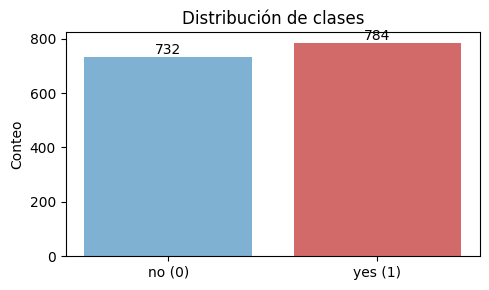

In [4]:
class_counts = df['is_suicide'].value_counts().sort_index()
class_ratio  = df['is_suicide'].value_counts(normalize=True).sort_index().round(4)

print('Conteo:')
print(class_counts)
print('\nProporción:')
print(class_ratio)

n_neg, n_pos = class_counts[0], class_counts[1]
scale_pos_weight = round(n_neg / n_pos, 4)
print(f'\nscale_pos_weight = n_neg / n_pos = {scale_pos_weight}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['no (0)', 'yes (1)'], class_counts.values, color=['#7fb1d3', '#d36a6a'])
ax.set_ylabel('Conteo')
ax.set_title('Distribución de clases')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 10, str(v), ha='center')
plt.tight_layout()
plt.show()

**Observación.** El dataset es **casi perfectamente balanceado** (51.7% positivos vs 48.3% negativos). Por eso `scale_pos_weight ≈ 0.93` y no es necesario hacer oversampling / undersampling — la diferencia es lo suficientemente pequeña para que XGBoost la maneje sola con ese parámetro.

## 4. Longitud de los textos

El siguiente bloque concatena `title + text` (la misma transformación que aplica el pipeline en producción) y mide la longitud en caracteres y en tokens (split por whitespace). Esto es la base para discutir el tema de outliers.

In [5]:
df = concatenate_df(df, ['title', 'text'])
df['n_chars']  = df['title_text'].str.len()
df['n_tokens'] = df['title_text'].str.split().str.len()

stats = df[['n_chars', 'n_tokens']].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]
).round(1)
stats

,n_chars,n_tokens
count,1516.0,1516.0
mean,956.7,183.0
std,1536.0,277.1
min,13.0,2.0
1%,33.2,7.0
5%,82.0,15.0
25%,271.8,54.0
50%,558.5,108.0
75%,1118.2,218.0
95%,2772.2,535.0


C:\Users\DiDi\AppData\Local\Temp\ipykernel_49388\417341638.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(by_class, labels=['no (0)', 'yes (1)'], showfliers=True, patch_artist=True)


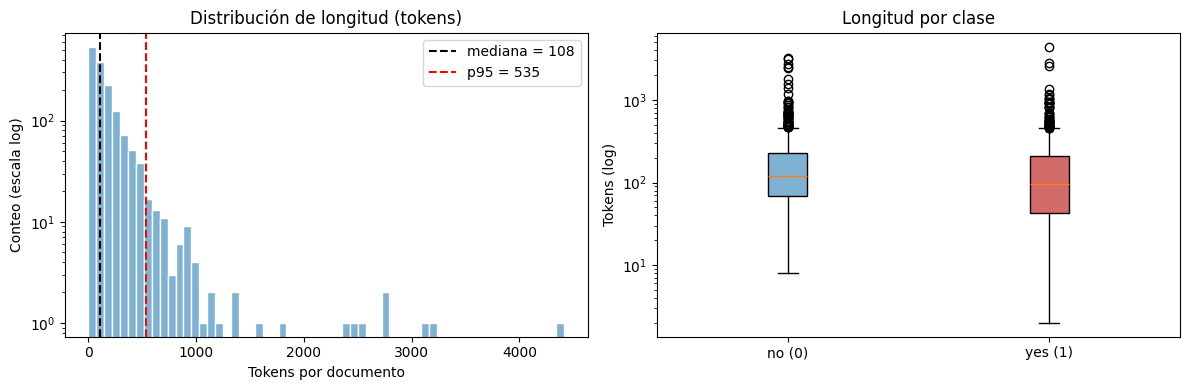

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma en escala log (los outliers extremos hacen ilegible el lineal)
axes[0].hist(df['n_tokens'], bins=60, color='#7fb1d3', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_xlabel('Tokens por documento')
axes[0].set_ylabel('Conteo (escala log)')
axes[0].set_title('Distribución de longitud (tokens)')
axes[0].axvline(df['n_tokens'].median(), color='black', linestyle='--', label=f'mediana = {df["n_tokens"].median():.0f}')
axes[0].axvline(df['n_tokens'].quantile(0.95), color='red', linestyle='--', label=f'p95 = {df["n_tokens"].quantile(0.95):.0f}')
axes[0].legend()

# Boxplot por clase
by_class = [df[df['is_suicide']==0]['n_tokens'], df[df['is_suicide']==1]['n_tokens']]
bp = axes[1].boxplot(by_class, labels=['no (0)', 'yes (1)'], showfliers=True, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#7fb1d3', '#d36a6a']):
    patch.set_facecolor(color)
axes[1].set_yscale('log')
axes[1].set_ylabel('Tokens (log)')
axes[1].set_title('Longitud por clase')

plt.tight_layout()
plt.show()

**Observación.** La distribución de longitudes es **fuertemente sesgada a la derecha**:

| Métrica | Caracteres | Tokens |
|---|---|---|
| mediana | ~559 | ~108 |
| p95 | ~2,772 | ~535 |
| p99 | ~5,927 | ~1,043 |
| máximo | 24,590 | 4,411 |

El máximo es ~40 veces la mediana en caracteres. **En texto, este sesgo es el caso normal**, no un defecto del dataset — algunos usuarios escriben unos cuantos renglones, otros escriben cartas largas.

El boxplot por clase muestra que **ambas clases tienen distribuciones similares**: la longitud por sí sola no separa suicida de no-suicida. Por eso no se va a usar la longitud como feature explícita; el TF-IDF ya captura cualquier señal indirecta que ahí exista.

## 5. "Outliers" de longitud — análisis y decisión

En texto, el concepto de "outlier" no es el mismo que en datos numéricos. Un documento de 10,000 palabras no es un "valor extremo" que distorsione una regresión — es simplemente un documento largo. Antes de decidir si se podan o no, vemos qué hay en los dos extremos.

In [7]:
# Extremo corto: ≤ 10 tokens
short = df[df['n_tokens'] <= 10].copy()
print(f'Posts con ≤10 tokens: {len(short)} ({100*len(short)/len(df):.1f}% del corpus)')
print('Distribución de clase entre los cortos:')
print(short['is_suicide'].value_counts())
print()
print('Muestra de los cortos (primeros 5):')
short[['title_text', 'is_suicide']].head(5)

Posts con ≤10 tokens: 46 (3.0% del corpus)
Distribución de clase entre los cortos:
is_suicide
1    41
0     5
Name: count, dtype: int64

Muestra de los cortos (primeros 5):


,title_text,is_suicide
126,I want to hurt myself [removed],1
149,I’m crying so hard Please help me,1
160,Been suffering for fucking 24 years Still fucking suffering,1
181,I think I’m ready [removed],1
211,NYC No point anymore I have no one,1


In [8]:
# Extremo largo: top 5 por número de tokens
long_top = df.nlargest(5, 'n_tokens')[['n_tokens', 'is_suicide', 'title_text']]
long_top['title_text'] = long_top['title_text'].str.slice(0, 200) + '...'
long_top

,n_tokens,is_suicide,title_text
706,4411,1,I dont know if its worth the read but this is my life this is how i feel and if you do read it can you answer the qu...
946,3200,0,Can I leave some baggage here I'm not sure if this is the place to post this but here we go. Apologies in advance th...
1057,3138,0,I think this is my final straw and I am scared Warning: this is VERY long. I'm not sure what the purpose of it reall...
1284,2758,1,"Stress and loneliness are dragging me down again After 29 years of being a shut in, sometimes having social anxiety ..."
707,2748,0,"My life story, I am sorry it's so long Hi there to all witches who take their craft seriously and really work, I am ..."


**Observación clave.** Los ~3% de posts más cortos están **fuertemente sesgados a la clase positiva** (alrededor del 89% son `yes`). Esto no es ruido: posts breves del tipo *"I want to die"* o *"how do I kill myself"* son una modalidad real de ideación suicida y representan **señal valiosa**, no contaminación.

Los posts más largos, por el otro lado, suelen ser narrativas extensas (cartas, descripciones de eventos traumáticos). También son señal legítima.

### Decisión: no se podan outliers de longitud

Razones, en orden:

1. **El TF-IDF normaliza por norma L2 a nivel documento** (default de `TfidfVectorizer`). Después de la normalización, un documento de 5,000 tokens y uno de 50 tokens tienen exactamente la misma magnitud en el espacio de features. La longitud no infla coeficientes.
2. **`sublinear_tf=True` aplica `1 + log(tf)`**, lo que aplasta aún más el efecto de palabras que aparecen muchas veces dentro de un mismo documento largo.
3. **`max_features=10000` limita el vocabulario global**. Un post enorme no agrega features nuevas al modelo; solo afecta su propia representación.
4. **XGBoost es un modelo basado en árboles**: a diferencia de una regresión logística, no es sensible a la magnitud absoluta de las features. Los outliers no "jalan" la frontera de decisión.
5. **Los posts cortos son 89% positivos.** Quitarlos sesgaría artificialmente el dataset hacia la clase negativa y eliminaría una modalidad real de ideación.
6. **Los posts largos contienen presumiblemente la señal más rica** (narrativa, contexto, planes concretos). Quitarlos sería peor.

En resumen: el pipeline (normalización L2 + sublinear_tf + max_features + modelo no-paramétrico) ya neutraliza estadísticamente la longitud, así que filtrar a mano por percentiles sería arbitrario y perjudicial.

## 6. Marcadores especiales del corpus: `[removed]` y `[deleted]`

En el dump original de Reddit, cuando un post o comentario es borrado, queda el placeholder `[removed]` (borrado por moderador) o `[deleted]` (borrado por el usuario). Revisamos cuántos hay y si hay sesgo de clase.

In [9]:
is_removed  = df['text'].str.strip() == '[removed]'
is_deleted  = df['text'].str.contains(r'\[deleted\]', regex=True, na=False)

print(f'Posts con text == "[removed]": {is_removed.sum()}')
print(f'Posts que contienen "[deleted]": {is_deleted.sum()}')
print()
print('Distribución de clase entre los [removed]:')
print(df.loc[is_removed, 'is_suicide'].value_counts())

Posts con text == "[removed]": 55
Posts que contienen "[deleted]": 0

Distribución de clase entre los [removed]:
is_suicide
1    54
0     1
Name: count, dtype: int64


**Observación.** Hay un puñado de posts con `text == "[removed]"`. Estos **siguen teniendo título**, así que después del `title + text` la información del título se preserva — no se pierde el caso.

**Sesgo importante:** el token `removed` aparece desproporcionadamente en la clase positiva (~55 veces en `yes` vs ~4 en `no`). Esto puede ser una **fuga sutil**: Reddit suele moderar más agresivamente contenido sensible, así que el placeholder `[removed]` correlaciona con "el post era de tipo crisis" más que con el texto que el usuario realmente escribió. El modelo puede aprender este atajo.

**Decisión por ahora:** se mantienen, sin tratamiento especial. Razones:

- Son solo ~3.6% del corpus, no dominan el entrenamiento.
- Quitarlos eliminaría señal real del título asociado.
- Mapearlos a un token especial (p. ej. `<REMOVED>`) sería una mejora válida, pero entra en el roadmap, no en el baseline.

Esto queda anotado como un sesgo conocido que vale la pena reportar en el análisis de errores.

## 7. Duplicados exactos

In [10]:
dup_id   = df['text_id'].duplicated().sum()
dup_text = df['title_text'].duplicated().sum()
print(f'Duplicados por text_id:  {dup_id}')
print(f'Duplicados por título+texto exacto: {dup_text}')

if dup_text > 0:
    print('\nEjemplos:')
    display(df[df['title_text'].duplicated(keep=False)].sort_values('title_text').head(6)[['user_id', 'is_suicide', 'title_text']])

Duplicados por text_id:  0
Duplicados por título+texto exacto: 5

Ejemplos:


,user_id,is_suicide,title_text
86,user0087,0,Drinking keeps me alive It used to be something I did once every couple weeks at a party when I was a teen. Now it m...
622,user0087,0,Drinking keeps me alive It used to be something I did once every couple weeks at a party when I was a teen. Now it m...
751,user0724,0,"Feeling empty It's not that I hate working but... no, it is precisely that I hate working. I just can't come to term..."
949,user0724,1,"Feeling empty It's not that I hate working but... no, it is precisely that I hate working. I just can't come to term..."
178,user0179,0,I need your advice I feel tired. Nothing brings me a joy. I lost all my fucking hobbies. I started smoking a lot. I ...
832,user0179,0,I need your advice I feel tired. Nothing brings me a joy. I lost all my fucking hobbies. I started smoking a lot. I ...


**Observación.** Hay un número pequeño de duplicados exactos por concatenación (típicamente 0–5). No hay duplicados por `text_id`, así que cada fila es un registro único — los textos repetidos vienen de usuarios distintos publicando el mismo contenido (cross-posting, copy-paste).

**Decisión:** se mantienen tal cual en el baseline. Cinco duplicados sobre ~1,500 filas es <0.5%, dentro del ruido del K-fold. Si en una iteración posterior se hace tuning fino con Optuna, conviene deduplicar para evitar que el mismo texto aparezca en train y val de un mismo fold (eso sí sería leakage).

## 8. Encoding corrupto (mojibake)

Una porción del corpus tiene caracteres mal codificados (UTF-8 leído como Latin-1, secuencias `â€™` en lugar de `'`, etc.). Detectamos qué tan común es.

In [11]:
MOJIBAKE_PATTERN = re.compile(r'[â€™œžŸšŠ¢�ÃÂ]|[\u0080-\u009F]')

df['has_mojibake'] = df['title_text'].apply(lambda s: bool(MOJIBAKE_PATTERN.search(s)) if isinstance(s, str) else False)

n_bad = df['has_mojibake'].sum()
print(f'Posts con caracteres de encoding corrupto: {n_bad} ({100*n_bad/len(df):.1f}%)')
print()
print('Ejemplo:')
ejemplo = df.loc[df['has_mojibake'], 'title_text'].iloc[0]
print(ejemplo[:300])

Posts con caracteres de encoding corrupto: 2 (0.1%)

Ejemplo:
Yesterday I turned 25 and I still wonder how I made it this far. I was the only thing that held their marriage or some sort together. Came to them today to have a family dinner tomorrow and they do nothing but arguing between each other over stupid shit. Guess they are so tired of each other they ai


In [12]:
# Demostrar que la reparación con ftfy resuelve el problema
from src.preprocessing import fix_encoding

print('Antes:')
print(ejemplo[:300])
print()
print('Después de fix_encoding():')
print(fix_encoding(ejemplo)[:300])

Antes:
Yesterday I turned 25 and I still wonder how I made it this far. I was the only thing that held their marriage or some sort together. Came to them today to have a family dinner tomorrow and they do nothing but arguing between each other over stupid shit. Guess they are so tired of each other they ai

Después de fix_encoding():
Yesterday I turned 25 and I still wonder how I made it this far. I was the only thing that held their marriage or some sort together. Came to them today to have a family dinner tomorrow and they do nothing but arguing between each other over stupid shit. Guess they are so tired of each other they ai


**Decisión.** La función `fix_encoding` (que usa `ftfy`) está integrada como primer paso de `clean_text` en `src/preprocessing.py`, así que estos casos se resuelven automáticamente antes de cualquier vectorización. Validado arriba con un caso real del corpus.

## 9. Vocabulario y palabras frecuentes

Para sustentar la decisión de **no usar una lista de stopwords explícita**, comparamos las palabras más frecuentes en cada clase.

In [13]:
def tokenize_lower(s):
    return re.findall(r'[a-z]+', s.lower())

c_pos = Counter()
c_neg = Counter()
for s in df.loc[df['is_suicide']==1, 'title_text']: c_pos.update(tokenize_lower(s))
for s in df.loc[df['is_suicide']==0, 'title_text']: c_neg.update(tokenize_lower(s))

top_pos = pd.DataFrame(c_pos.most_common(15), columns=['palabra', 'freq_yes'])
top_neg = pd.DataFrame(c_neg.most_common(15), columns=['palabra', 'freq_no'])

comparativo = top_pos.merge(top_neg, on='palabra', how='outer').fillna(0).sort_values('freq_yes', ascending=False)
comparativo.head(15)

,palabra,freq_yes,freq_no
4,i,11136,11719
14,to,4869,5017
1,and,3954,4475
9,my,2865,3060
13,the,2735,3165
0,a,2425,2712
6,it,2121,2283
11,t,2064,2163
8,me,1930,2028
7,m,1863,1772


**Observación.** Las palabras más frecuentes en ambas clases son **prácticamente idénticas**: `i`, `to`, `and`, `the`, `my`, `a`, `it`, etc. Son las stopwords típicas del inglés.

### Justificación de no usar stopwords explícitas

El `TfidfVectorizer` está configurado con `max_df=0.95`, lo que significa que **cualquier término que aparezca en más del 95% de los documentos se filtra automáticamente**. Las palabras de la tabla de arriba caen en ese grupo, así que la matriz TF-IDF no las usa como features.

Por qué esto es preferible a una lista hardcoded de stopwords (`nltk.corpus.stopwords.words('english')`):

- **Adaptativo al corpus.** Si en otro dataset una palabra "funcional" como `would` se vuelve discriminativa, `max_df` la deja pasar. Una lista fija la quitaría siempre.
- **No pierde tokens relevantes.** Las listas estándar de NLTK quitan palabras como `not`, `no`, `down`, `against` — todas potencialmente relevantes en este dominio.
- **Una sola fuente de verdad.** Toda la lógica de filtrado vive en la config YAML, no repartida entre código de preprocesamiento y la vectorización.

Adicionalmente, `min_df=2` elimina los hapax legomena (palabras que aparecen una sola vez), que no aportan poder de generalización.

## 10. Palabras más discriminativas

Más allá de las frecuencias absolutas, queremos saber qué palabras aparecen **mucho más en una clase que en la otra**. Esto da intuición de qué señal va a aprender el modelo.

In [14]:
MIN_COUNT = 30  # solo palabras con suficiente soporte

rows = []
for w in set(c_pos) | set(c_neg):
    np_, nn_ = c_pos.get(w, 0), c_neg.get(w, 0)
    if np_ + nn_ < MIN_COUNT:
        continue
    # Laplace-smoothed ratio
    ratio = (np_ + 1) / (nn_ + 1)
    rows.append((w, np_, nn_, round(ratio, 2)))

disc = pd.DataFrame(rows, columns=['palabra', 'freq_yes', 'freq_no', 'ratio_yes/no'])

print('Top 15 sobre-representadas en YES (ideación suicida):')
display(disc.sort_values('ratio_yes/no', ascending=False).head(15))

print('\nTop 15 sobre-representadas en NO (otros temas / depresión general):')
display(disc.sort_values('ratio_yes/no').head(15))

Top 15 sobre-representadas en YES (ideación suicida):

,palabra,freq_yes,freq_no,ratio_yes/no
576,john,35,0,36.00
220,l,81,3,20.50
808,removed,55,4,11.20
407,attempted,40,5,6.83
374,n,40,5,6.83
704,u,116,18,6.16
106,w,42,6,6.14
592,abused,27,4,5.60
543,e,41,8,4.67
783,commit,29,6,4.29



Top 15 sobre-representadas en NO (otros temas / depresión general):


,palabra,freq_yes,freq_no,ratio_yes/no
158,worry,15,67,0.24
666,brain,15,62,0.25
121,explain,7,30,0.26
261,group,14,51,0.29
475,seeing,15,47,0.33
302,angry,13,40,0.34
66,wonder,10,31,0.34
136,tells,8,25,0.35
237,depressive,8,25,0.35
775,dealing,9,26,0.37


**Observaciones.**

- **Lado `yes`** dominado por vocabulario explícito sobre el tema: `suicide`, `attempt`, `attempted`, `commit`, `plan`, `note`, `abused`. Esto es exactamente la señal que esperaríamos, lo cual valida que el dataset está bien etiquetado.
- **`removed`** aparece muy sesgado a `yes`, confirmando el sesgo de moderación discutido en la sección 6.
- **`john`** con conteo 35 en `yes` y 0 en `no` es **sospechoso**. Probablemente un usuario específico aparece varias veces en train con la clase positiva (overlap de `user_id`). Esto refuerza la nota del README sobre user-disjoint splits — para una versión más rigurosa, valdría la pena estratificar por usuario.
- **Letras sueltas (`l`, `n`, `w`, `u`, `e`)** aparecen como tokens porque el preprocessing parte contracciones (`I'm` → `I`, `m`). Es ruido leve; no afecta el AUC pero podría limpiarse con un regex que conserve contracciones.
- **Lado `no`** sobre-representa términos como `worry`, `brain`, `depression`, `negative`, `wonder`. Tiene sentido: muchos posts en `no` son discusiones de salud mental que **no** son ideación suicida activa (síntomas, descripciones de depresión, dudas generales). El modelo está aprendiendo a separar "hablar sobre salud mental" de "expresar intención inmediata".

## 11. Resumen de decisiones de diseño

Cada decisión derivada de este EDA, en una tabla.

| Aspecto | Decisión | Justificación (sección) |
|---|---|---|
| Class balance | `scale_pos_weight = n_neg/n_pos ≈ 0.93`, sin oversampling | §3 — el desbalance es chico |
| Outliers de longitud (cortos) | **No se filtran** | §5 — son 89% positivos, son señal real |
| Outliers de longitud (largos) | **No se filtran** | §5 — TF-IDF + L2 norm + sublinear_tf + XGBoost los neutraliza |
| `[removed]` / `[deleted]` | Se mantienen | §6 — pocos casos, título preserva señal; se anota como sesgo conocido |
| Duplicados exactos | Se mantienen en baseline | §7 — <0.5% del corpus, dentro del ruido |
| Encoding corrupto | Reparado en `clean_text` con `ftfy` | §8 — validado con caso real |
| Stopwords | **Sin lista explícita**; se confía en `max_df=0.95` | §9 — adaptativo al corpus, no pierde tokens relevantes |
| Hapax legomena | Filtrados con `min_df=2` | §9 — no generalizan |
| `user_id` overlap train/test | Conocido, sin acción inmediata | §10 — anotado en el roadmap como user-disjoint splits |

**Lo que NO se hace y por qué:**

- **No se aplica stemming/lemmatization.** Con ~1,500 muestras y vocabulario controlado por `max_features=10000`, la reducción de variantes morfológicas no compensa la pérdida de información (`died`, `dying`, `die` pueden tener perfiles de uso distintos). Posible mejora futura si el AUC se estanca.
- **No se ajusta umbral todavía.** El default 0.5 se mantiene en el baseline; bajarlo a 0.35–0.4 para priorizar recall es una optimización post-baseline (ver roadmap).
- **No se entrena un modelo de palabras embebidas (word2vec, GloVe).** Para ~1,500 docs el TF-IDF supera a embeddings preentrenados en F1, salvo que se haga fine-tuning de un modelo grande — fuera de scope para el enfoque clásico.